<a href="https://colab.research.google.com/github/MankotiaGit/Statistical-Foundation-of-Data-Sciences-/blob/main/SFDS_PRACTICAL_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Step 1: Import required libraries

Step 2: Load the iris dataset

Step 3: Create dataframe and add target/species columns

Step 4: Perform eda using head(), describe(), and groupby()

Step 5: Split the dataset and perform feature scaling

Step 6: Train the knn model using k = 5

Step 7: Calculate confusion matrix and accuracy score

Step 8: Generate the classification report

Step 9: Compare error rate for k values from 1 to 20

Step 10: Plot error rate against k values

Step 11: Find the best k value

Step 12: Train the final knn model using the best k

Step 13: Calculate the final accuracy

Step 14: Visualize the test results of knn

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Imports NumPy, Pandas, Matplotlib, and Seaborn for data analysis and visualization.

In [3]:
from matplotlib.colors import ListedColormap
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

Imports the Iris dataset, train-test split, feature scaling, KNN algorithm, and evaluation metrics.


In [4]:
iris = load_iris(as_frame=True)
df = iris.frame.copy()
df["species"] = df["target"].map(dict(enumerate(iris.target_names)))

Loads the Iris dataset, converts it into a DataFrame, and adds species names.

In [5]:
#Step 1: EDA - head() , describe () , groupby()
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris

# Load Iris dataset
iris = load_iris()

# Create DataFrame
df = pd.DataFrame(iris.data, columns=iris.feature_names)

# Add target column
df['target'] = iris.target

# Add species names
df['species'] = df['target'].map({
    0: 'setosa',
    1: 'versicolor',
    2: 'virginica'
})

# Display first 5 rows
print("First 5 rows:")
display(df.head())

# Statistical description
print("\nStatistical Description:")
display(df.describe())

# Groupby species
print("\nGroupby Species:")
display(df.groupby('species').mean(numeric_only=True))

---- head() ----
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target species  
0       0  setosa  
1       0  setosa  
2       0  setosa  
3       0  setosa  
4       0  setosa  

---- info() ----
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   15

Performs EDA using head(), describe(), and groupby() to understand the Iris dataset.

In [14]:
#Step 2: Feature scaling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Features
X = df[iris.feature_names]

# Target
y = df['target']

# Split dataset into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Feature scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Feature scaling completed.")
print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Feature scaling completed.
Training data shape: (120, 4)
Testing data shape: (30, 4)


Splits the data into training/testing sets and scales the features using StandardScaler.

In [15]:
#Step 3: Training the K-NN model on the Training set

from sklearn.neighbors import KNeighborsClassifier

# Create KNN model
knn = KNeighborsClassifier(n_neighbors=5)

# Train the model
knn.fit(X_train, y_train)

print("K-NN model trained successfully.")

K-NN model trained successfully.


Creates and trains the KNN model using K = 5.

Accuracy Score: 0.9333333333333333
Accuracy Percentage: 93.33333333333333 %

Confusion Matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  2  8]]


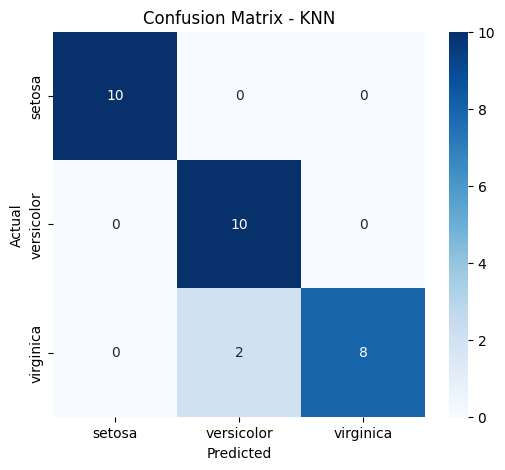

In [16]:
#Step 4: Making the Confusion Matrix & Predicting Accuracy Score

from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# Make predictions
y_pred = knn.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy Score:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

# Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - KNN")
plt.show()

Predicts the test data, calculates accuracy, and displays the confusion matrix.

In [23]:
#Step 5: Making Classification Report

from sklearn.metrics import classification_report

print("Classification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=iris.target_names
    )
)

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



Generates the classification report showing precision, recall, F1-score, and support for each Iris species.


In [18]:
#Step 6: Comparing Error Rate with the K Value
error_rate = []

for k in range(1, 21):

    knn_k = KNeighborsClassifier(n_neighbors=k)
    knn_k.fit(X_train, y_train)

    pred_k = knn_k.predict(X_test)

    error = 1 - accuracy_score(y_test, pred_k)
    error_rate.append(error)

print("K values:", list(range(1, 21)))
print("Error rates:", error_rate)

K values: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
Error rates: [0.033333333333333326, 0.06666666666666665, 0.06666666666666665, 0.06666666666666665, 0.06666666666666665, 0.06666666666666665, 0.033333333333333326, 0.06666666666666665, 0.033333333333333326, 0.033333333333333326, 0.033333333333333326, 0.033333333333333326, 0.033333333333333326, 0.033333333333333326, 0.033333333333333326, 0.033333333333333326, 0.033333333333333326, 0.033333333333333326, 0.033333333333333326, 0.033333333333333326]


Tests K values from 1 to 20 and calculates the error rate for each K value.


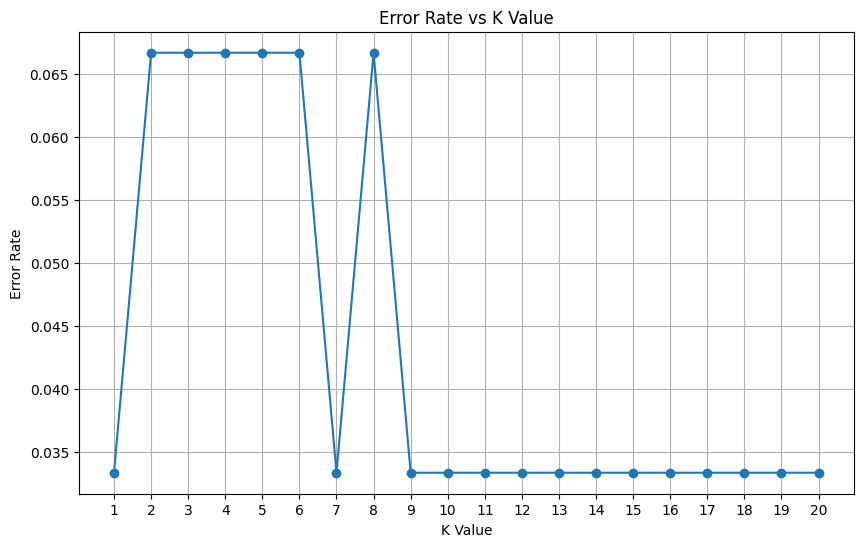

In [19]:
#Step 7: Plot the error values against K values
plt.figure(figsize=(10, 6))

plt.plot(
    range(1, 21),
    error_rate,
    marker='o',
    linestyle='-'
)

plt.xlabel("K Value")
plt.ylabel("Error Rate")
plt.title("Error Rate vs K Value")
plt.xticks(range(1, 21))
plt.grid(True)

plt.show()

Plots the error rate for K values from 1 to 20 to help identify the best K value.


In [20]:
#Step 8: Finding best K
best_k = range(1, 21)[np.argmin(error_rate)]
lowest_error = min(error_rate)

print("Best K value:", best_k)
print("Lowest Error Rate:", lowest_error)
print("Best Accuracy:", (1 - lowest_error) * 100, "%")

Best K value: 1
Lowest Error Rate: 0.033333333333333326
Best Accuracy: 96.66666666666667 %


Finds the K value with the lowest error rate and calculates its accuracy.

In [21]:
# Train final KNN model using the best K

final_knn = KNeighborsClassifier(n_neighbors=best_k)

final_knn.fit(X_train, y_train)

# Predictions
final_pred = final_knn.predict(X_test)

# Final accuracy
final_accuracy = accuracy_score(y_test, final_pred)

print("Final K:", best_k)
print("Final Accuracy:", final_accuracy * 100, "%")

Final K: 1
Final Accuracy: 96.66666666666667 %


Trains the final KNN model using the best K value and calculates its final accuracy.


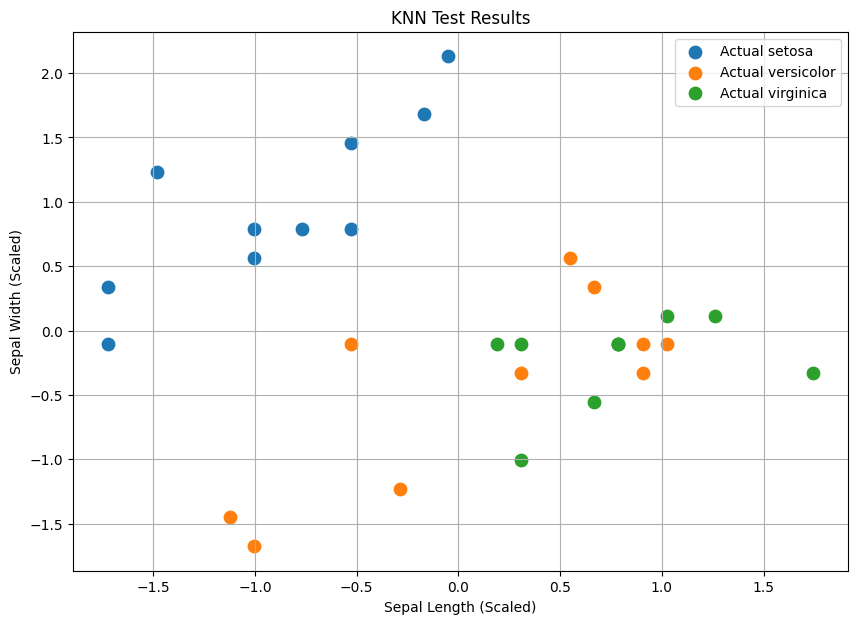

In [22]:
# Step 9: Visualize Test Result of KNN
plt.figure(figsize=(10, 7))

# Plot actual test data
for class_value, class_name in enumerate(iris.target_names):

    plt.scatter(
        X_test[y_test.values == class_value, 0],
        X_test[y_test.values == class_value, 1],
        label=f"Actual {class_name}",
        s=80
    )

plt.xlabel("Sepal Length (Scaled)")
plt.ylabel("Sepal Width (Scaled)")
plt.title("KNN Test Results")
plt.legend()
plt.grid(True)

plt.show()

Visualizes the test data points for the three Iris species to understand the KNN classification results.